# **Bank Marketing**

**Note:** This is a pretty rough first look, but can help decide which is easiest to work w/

**Link:** https://archive.ics.uci.edu/dataset/222/bank+marketing

This is the easiest of the bunch, and does not have a bloated feature count. There are only a few features that have missing data, so it would be an easy fix, and no features are super correlated with one another, so that makes this dataset easy to work with. Out of all the datasets viewed so far, this one probably has the greatest potential for feature engineering applications, or at the very least, adding boolean columns like `..._was_missing` to give greater detail to a RF model.

No complaints about this one, besides stating that it may be 'too easy' for the professors goals, so its worth keeping in mind.

Also classification.

---

In [19]:
# Global imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

In [20]:
# This is the only thing that really needs to change when looking from dataset to dataset, run everything else that follows as normal

DATA_PATH = "bank-full.csv"  # 45,211 rows, 17 attributes — the version referenced throughout
SEP = ";"              # this file is semicolon-delimited, not comma
SKIPROWS = 0           # header row is already present, no metadata block
NA_VALUES = "unknown"  # categorical columns use this as their missing-value marker
TARGET_COL = "y"       # yes/no term deposit subscription
TOP_K = 30

In [21]:
# Load the data

df = pd.read_csv(DATA_PATH, sep=SEP, skiprows=SKIPROWS, na_values=NA_VALUES)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no
5,35,management,married,tertiary,no,231,yes,no,NaN,5,may,139,1,-1,0,NaN,no
6,28,management,single,tertiary,no,447,yes,yes,NaN,5,may,217,1,-1,0,NaN,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,NaN,5,may,380,1,-1,0,NaN,no
8,58,retired,married,primary,no,121,yes,no,NaN,5,may,50,1,-1,0,NaN,no
9,43,technician,single,secondary,no,593,yes,no,NaN,5,may,55,1,-1,0,NaN,no


In [22]:
# Basic info

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        44923 non-null  str  
 2   marital    45211 non-null  str  
 3   education  43354 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    32191 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   8252 non-null   str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [24]:
if TARGET_COL in df.columns:
    print(df[TARGET_COL].value_counts())
    print()
    print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
else:
    print(f"Column '{TARGET_COL}' not found — update TARGET_COL in the config cell.")

# highly imbalanced

y
no     39922
yes     5289
Name: count, dtype: int64

y
no     88.3 %
yes    11.7 %
Name: proportion, dtype: str


In [25]:
# Null value check

null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
 
null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)
 
print(f"Columns with at least one missing value: {len(null_summary)} / {df.shape[1]}")
null_summary.head(30)

Columns with at least one missing value: 4 / 17


,n_missing,pct_missing
poutcome,36959,81.75
contact,13020,28.80
education,1857,4.11
job,288,0.64


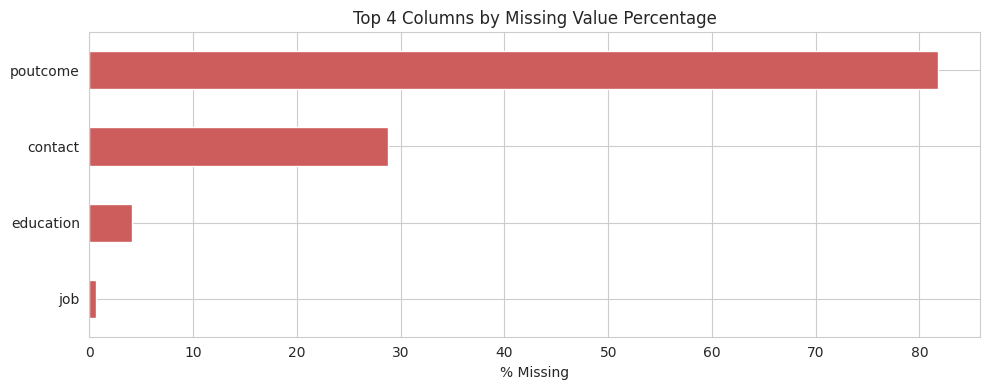

In [26]:
top_n_missing = min(25, len(null_summary))
 
if top_n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, top_n_missing * 0.3)))
    null_summary.head(top_n_missing)["pct_missing"].sort_values().plot(
        kind="barh", ax=ax, color="indianred"
    )
    ax.set_xlabel("% Missing")
    ax.set_title(f"Top {top_n_missing} Columns by Missing Value Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

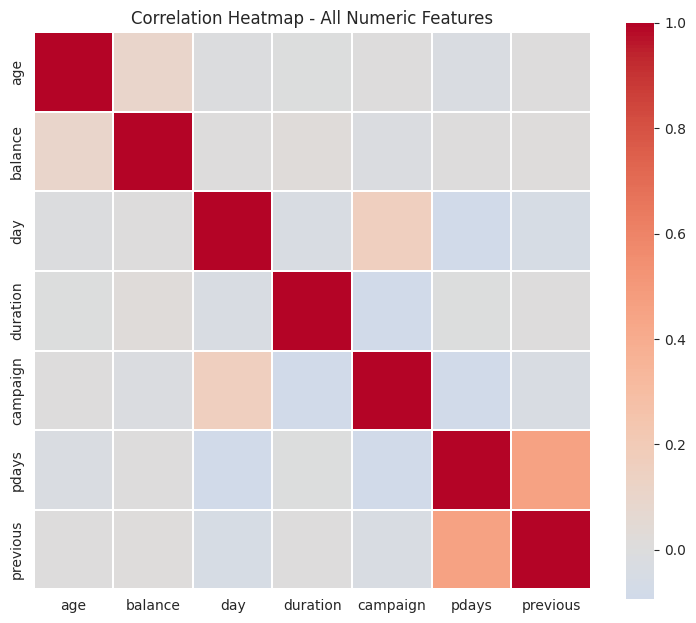

In [27]:
# Correlation heatmap

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
 
if TOP_K is not None and TOP_K < len(numeric_df.columns):
    avg_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
    plot_cols = avg_abs_corr.head(TOP_K).index
    heatmap_title = f"Correlation Heatmap - Top {TOP_K} Most Correlated Features"
else:
    plot_cols = numeric_df.columns
    heatmap_title = "Correlation Heatmap - All Numeric Features"
 
fig, ax = plt.subplots(figsize=(min(24, len(plot_cols) * 0.5 + 4), min(20, len(plot_cols) * 0.5 + 4)))
sns.heatmap(
    corr_matrix.loc[plot_cols, plot_cols],
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title(heatmap_title)
plt.tight_layout()
plt.show()

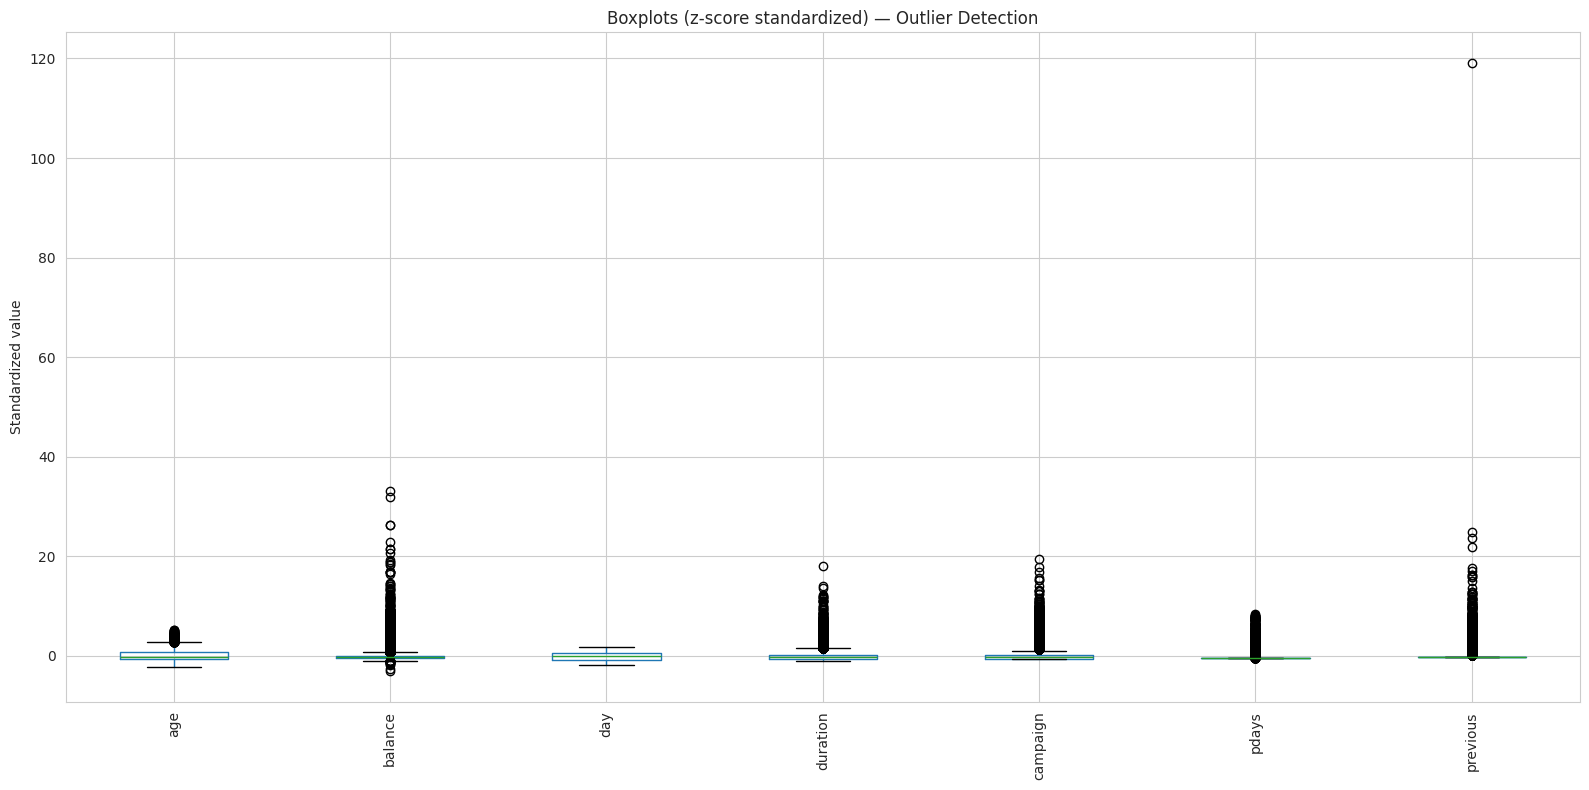

In [28]:
boxplot_cols = plot_cols[:20]  # cap at 20 for readability regardless of TOP_K
standardized = numeric_df[boxplot_cols].apply(zscore, nan_policy="omit")
 
fig, ax = plt.subplots(figsize=(16, 8))
standardized.boxplot(ax=ax, rot=90)
ax.set_title("Boxplots (z-score standardized) — Outlier Detection")
ax.set_ylabel("Standardized value")
plt.tight_layout()
plt.show()

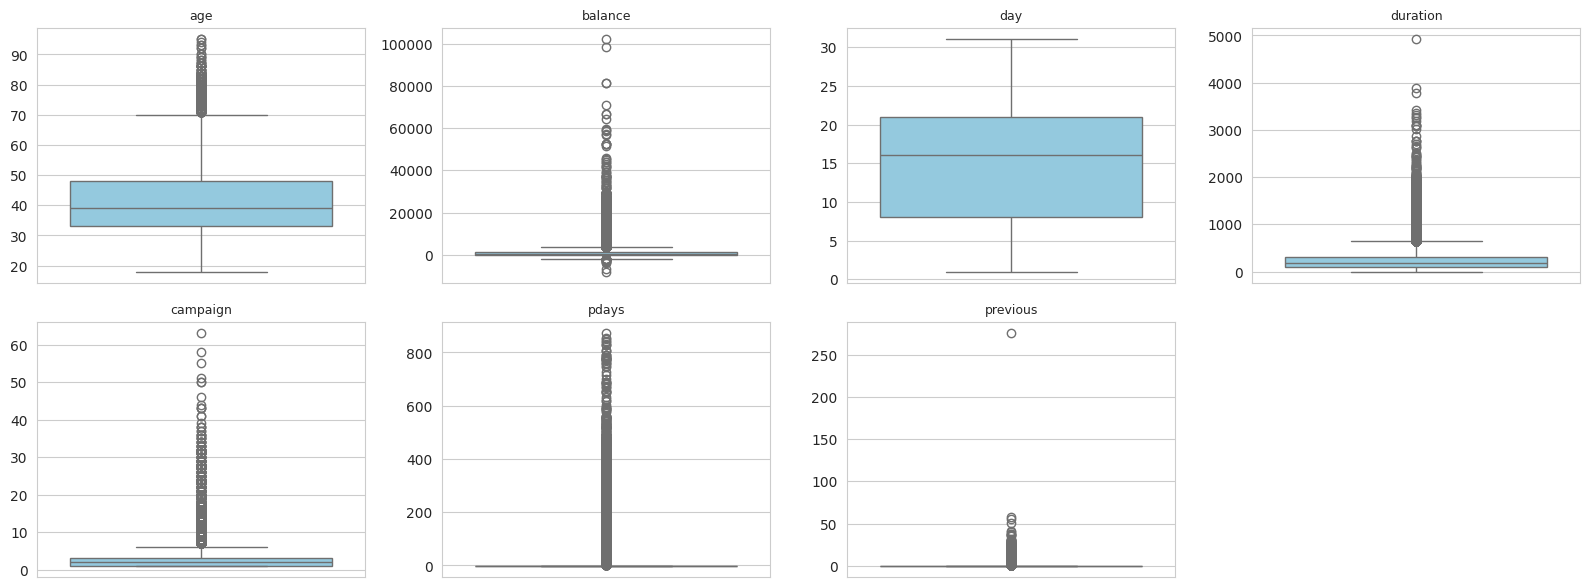

In [29]:
n_cols = 4
n_rows = int(np.ceil(len(boxplot_cols) / n_cols))
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
 
for i, col in enumerate(boxplot_cols):
    sns.boxplot(y=numeric_df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
 
for j in range(len(boxplot_cols), len(axes)):
    axes[j].axis("off")
 
plt.tight_layout()
plt.show()

In [30]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())
 
outlier_counts = (
    numeric_df[boxplot_cols]
    .apply(iqr_outlier_count)
    .sort_values(ascending=False)
    .to_frame("n_outliers")
)
outlier_counts["pct_outliers"] = (outlier_counts["n_outliers"] / len(numeric_df) * 100).round(2)
outlier_counts

,n_outliers,pct_outliers
previous,8257,18.26
pdays,8257,18.26
balance,4729,10.46
duration,3235,7.16
campaign,3064,6.78
age,487,1.08
day,0,0.00
